# Session 10 — Generative AI & Large Language Models

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-10-genai-llms.ipynb)

**ML/AI & GenAI Internship** · GenAI · Tokens, context & temperature · Leading LLMs · Prompt engineering · Prompt types

---

## How to use this notebook

**Session 9 ended with next-token prediction. This is what that becomes at scale.**

| # | Topic |
|---|---|
| 1 | What Generative AI is |
| 2 | LLM anatomy: tokens, parameters, context, temperature |
| 3 | Leading LLMs and what they are for |
| 4 | Prompt Engineering Basics |
| 5 | Types of Prompts: zero-, one-, few-shot, Chain-of-Thought |

> **You need a free [Google AI Studio](https://aistudio.google.com/) API key** for the cells marked 🔑. Everything else runs without one — see [setup-guide.md](../setup-guide.md).

Exercises, MCQs and tasks: [Session 10 guide](../sessions/session-10-genai-llms.md).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, json
import numpy as np
import matplotlib.pyplot as plt

# --- Your API key. getpass HIDES what you type, so it never lands in the
# --- notebook file. NEVER paste a key directly into a cell.
#
#     from getpass import getpass
#     os.environ["GEMINI_API_KEY"] = getpass("Gemini API key: ")
#
# In Colab, prefer Secrets (the key icon in the left sidebar):
#     from google.colab import userdata
#     os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

HAS_KEY = bool(os.environ.get("GEMINI_API_KEY"))
client = None
if HAS_KEY:
    from google import genai
    client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

def ask(prompt, **cfg):
    """Send a prompt, or show it if no key is set so the notebook still runs."""
    if not HAS_KEY:
        print("[no API key set - here is the prompt that WOULD be sent]\n")
        print(prompt)
        return None
    from google.genai import types
    r = client.models.generate_content(
        model="gemini-3.5-flash", contents=prompt,
        config=types.GenerateContentConfig(**cfg) if cfg else None)
    print(r.text)
    return r.text

print("API key set:", HAS_KEY)
print("Cells marked 🔑 need one; everything else runs regardless.")

API key set: False
Cells marked 🔑 need one; everything else runs regardless.


---
# 1. What Generative AI is

Every model in Sessions 5–8 **chose from options that already existed**. Generative models **produce something that did not exist before**.

🧠 **A music critic and a musician.** The critic listens and classifies — *this is jazz, this is three stars*. Useful, and bounded. The musician **writes a piece that has never been played.**

| | Predictive AI | Generative AI |
|---|---|---|
| Output | A label or a number | New text, images, audio, code |
| Question | *Which one?* | *Make me one* |
| Answer space | Fixed and known | Effectively unlimited |

In [2]:
tasks = [
    ("Will this customer churn?",                    "Predictive"),
    ("Write the email asking them to stay",          "Generative"),
    ("Is this transaction fraud?",                   "Predictive"),
    ("Explain why their card was blocked",           "Generative"),
    ("Compute this month's tax from published bands", "NEITHER - use a rule"),
]
for t, kind in tasks:
    print(f"{t:<48} {kind}")

print("\nThe best applications use BOTH: a model that DECIDES and a model")
print("that EXPLAINS. That is Session 11.")
print("\nAnd note the last row: Session 4's lesson still holds. If you can")
print("write the rule correctly, write the rule.")

Will this customer churn?                        Predictive
Write the email asking them to stay              Generative
Is this transaction fraud?                       Predictive
Explain why their card was blocked               Generative
Compute this month's tax from published bands    NEITHER - use a rule

The best applications use BOTH: a model that DECIDES and a model
that EXPLAINS. That is Session 11.

And note the last row: Session 4's lesson still holds. If you can
write the rule correctly, write the rule.


In [3]:
# 🔑 Your first API call.
ask("Explain overfitting to a first-year student in three sentences.")

[no API key set - here is the prompt that WOULD be sent]

Explain overfitting to a first-year student in three sentences.


---
# 2. Large Language Models: tokens, parameters, context

An LLM is a very large neural network — **exactly the kind you built in Session 9** — trained to predict the next token.

In [4]:
# Text is not processed as WORDS. It is processed as TOKENS.
text = "Machine learning models predict the next token, repeatedly."

try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained("gpt2")
    pieces = [tok.decode([i]) for i in tok.encode(text)]
    source = "real GPT-2 tokenizer"
except Exception:
    pieces = text.replace(",", " ,").replace(".", " .").split()
    pieces = [(" " + p if i else p) for i, p in enumerate(pieces)]
    source = "approximation (transformers not available)"

print(f"[{source}]\n")
print(f"{len(text.split())} words  ->  {len(pieces)} tokens\n")
print(pieces)
print("\nNotice the LEADING SPACES: ' learning' and 'learning' are DIFFERENT")
print("tokens. That is why models sometimes behave oddly around spacing.")
print("\nRough rule: 1 token ~ 4 characters ~ 3/4 of a word.")
print(f"So a 500-word essay is about {int(500/0.75)} tokens.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.

[real GPT-2 tokenizer]

8 words  ->  10 tokens

['Machine', ' learning', ' models', ' predict', ' the', ' next', ' token', ',', ' repeatedly', '.']

Notice the LEADING SPACES: ' learning' and 'learning' are DIFFERENT
tokens. That is why models sometimes behave oddly around spacing.

Rough rule: 1 token ~ 4 characters ~ 3/4 of a word.
So a 500-word essay is about 666 tokens.


In [5]:
# Context window: how much the model can SEE at once - prompt AND answer.
print(f"{'model era':<20}{'context':>12}{'~words':>11}{'~pages':>9}")
print("-" * 52)
for name, ctx in [("GPT-2 (2019)", 1024), ("GPT-3.5", 4096),
                  ("Llama 3", 8192), ("Gemini 1.5 Pro", 1_000_000)]:
    print(f"{name:<20}{ctx:>12,}{int(ctx*0.75):>11,}{ctx*0.75/500:>9,.0f}")

print("\nAnything beyond the window is simply NOT THERE. That is why long")
print("chats start 'forgetting' the beginning - the model is not forgetting,")
print("it can no longer see those tokens.")
print()
print("A 1M-token context is not free:")
print("  - you pay per input token")
print("  - the model is slower on long inputs")
print("  - facts buried in the MIDDLE of a long context are recalled")
print("    measurably worse than those at the start or the end")
print("Send what is RELEVANT, not everything you have.")

model era                context     ~words   ~pages
----------------------------------------------------
GPT-2 (2019)               1,024        768        2
GPT-3.5                    4,096      3,072        6
Llama 3                    8,192      6,144       12
Gemini 1.5 Pro         1,000,000    750,000    1,500

Anything beyond the window is simply NOT THERE. That is why long
chats start 'forgetting' the beginning - the model is not forgetting,
it can no longer see those tokens.

A 1M-token context is not free:
  - you pay per input token
  - the model is slower on long inputs
  - facts buried in the MIDDLE of a long context are recalled
    measurably worse than those at the start or the end
Send what is RELEVANT, not everything you have.


In [6]:
# TEMPERATURE: how sharply the model samples from its next-token probabilities.
logits = np.array([3.2, 2.1, 1.8, 0.9, 0.4, -0.3])
words  = ["sunny", "cloudy", "raining", "cold", "windy", "purple"]

def softmax_T(z, T):
    if T <= 0:
        p = np.zeros_like(z); p[np.argmax(z)] = 1.0; return p
    e = np.exp((z - z.max()) / T)
    return e / e.sum()

temps = [0.0, 0.3, 0.7, 1.0, 1.5, 2.5]
P = {T: softmax_T(logits, T) for T in temps}

print('After "Tomorrow will be ..." the model has these six candidates:\n')
print(f"{'token':<10}" + "".join(f"T={T:<6}" for T in temps))
print("-" * 58)
for i, w in enumerate(words):
    print(f"{w:<10}" + "".join(f"{P[T][i]:<8.3f}" for T in temps))

print(f'\nAt temperature 2.5, "Tomorrow will be PURPLE" has a {P[2.5][-1]:.1%} chance.')
print("That is what 'creative' settings actually mean, and why they")
print("produce incoherence.")

After "Tomorrow will be ..." the model has these six candidates:

token     T=0.0   T=0.3   T=0.7   T=1.0   T=1.5   T=2.5   
----------------------------------------------------------
sunny     1.000   0.966   0.711   0.565   0.427   0.314   
cloudy    0.000   0.025   0.148   0.188   0.205   0.202   
raining   0.000   0.009   0.096   0.139   0.168   0.179   
cold      0.000   0.000   0.027   0.057   0.092   0.125   
windy     0.000   0.000   0.013   0.034   0.066   0.102   
purple    0.000   0.000   0.005   0.017   0.041   0.077   

At temperature 2.5, "Tomorrow will be PURPLE" has a 7.7% chance.
That is what 'creative' settings actually mean, and why they
produce incoherence.


T=0.0:  sunny, sunny, sunny, sunny, sunny, sunny, sunny, sunny, sunny, sunny, sunny, sunny
T=0.7:  sunny, sunny, cloudy, cold, sunny, sunny, sunny, sunny, sunny, cold, sunny, sunny
T=1.5:  cold, cloudy, cloudy, raining, sunny, raining, sunny, sunny, raining, windy, sunny, cloudy


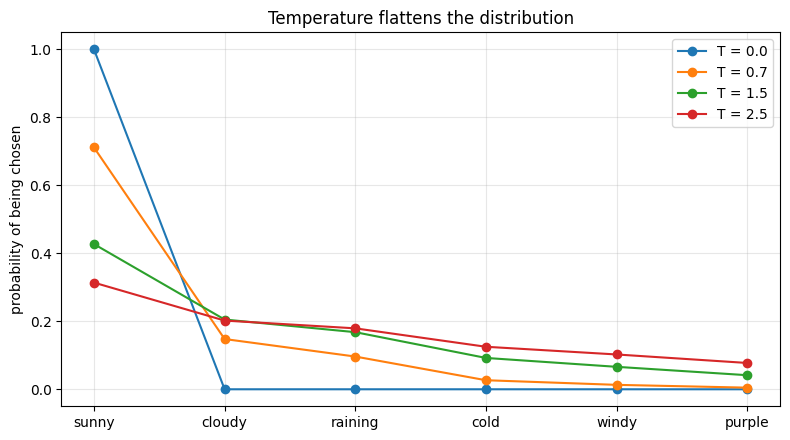

0.0 - 0.3   extraction, classification, JSON, anything factual
0.7         general writing. The usual default
1.0+        brainstorming, where you WANT variety


In [7]:
# Watch it sample.
rng = np.random.default_rng(3)
for T in [0.0, 0.7, 1.5]:
    picks = [words[rng.choice(len(words), p=softmax_T(logits, T))] for _ in range(12)]
    print(f"T={T}:  {', '.join(picks)}")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(words))
for T in [0.0, 0.7, 1.5, 2.5]:
    ax.plot(x, P[T], "o-", label=f"T = {T}")
ax.set_xticks(x); ax.set_xticklabels(words)
ax.set_ylabel("probability of being chosen")
ax.set_title("Temperature flattens the distribution")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("0.0 - 0.3   extraction, classification, JSON, anything factual")
print("0.7         general writing. The usual default")
print("1.0+        brainstorming, where you WANT variety")

---
# 3. Leading LLMs, and what they are for

The question is rarely *"which is best?"* — that changes monthly. **The useful questions are: open or closed, and what is it built to do?**

In [8]:
models = [
    ("GPT",     "OpenAI",    "no",  "decoder-only",    "general generation and chat"),
    ("Gemini",  "Google",    "no",  "decoder-only",    "general, multimodal, long context"),
    ("Claude",  "Anthropic", "no",  "decoder-only",    "long-form reasoning and code"),
    ("LLaMA",   "Meta",      "YES", "decoder-only",    "open general-purpose; base for fine-tunes"),
    ("Mistral", "Mistral AI","YES", "decoder-only",    "efficient, strong for its size"),
    ("Falcon",  "TII",       "YES", "decoder-only",    "open general-purpose"),
    ("BERT",    "Google",    "YES", "ENCODER-only",    "UNDERSTANDING text, not generating it"),
    ("T5",      "Google",    "YES", "encoder-decoder", "text-to-text: translate, summarise"),
]
print(f"{'model':<9}{'by':<11}{'open?':<7}{'architecture':<17}{'built for'}")
print("-" * 88)
for m in models:
    print(f"{m[0]:<9}{m[1]:<11}{m[2]:<7}{m[3]:<17}{m[4]}")

print("\nBERT CANNOT CHAT WITH YOU. This is the most common misunderstanding")
print("in this topic. BERT is an ENCODER: it reads text in both directions")
print("to understand it deeply. It was never trained to continue a sequence")
print("one token at a time. Asking it to write an email is a category error.")
print()
print("BERT is a READER.  GPT is a WRITER.  T5 is a TRANSLATOR.")

model    by         open?  architecture     built for
----------------------------------------------------------------------------------------
GPT      OpenAI     no     decoder-only     general generation and chat
Gemini   Google     no     decoder-only     general, multimodal, long context
Claude   Anthropic  no     decoder-only     long-form reasoning and code
LLaMA    Meta       YES    decoder-only     open general-purpose; base for fine-tunes
Mistral  Mistral AI YES    decoder-only     efficient, strong for its size
Falcon   TII        YES    decoder-only     open general-purpose
BERT     Google     YES    ENCODER-only     UNDERSTANDING text, not generating it
T5       Google     YES    encoder-decoder  text-to-text: translate, summarise

BERT CANNOT CHAT WITH YOU. This is the most common misunderstanding
in this topic. BERT is an ENCODER: it reads text in both directions
to understand it deeply. It was never trained to continue a sequence
one token at a time. Asking it to write a

In [9]:
# The decision you will actually make: open or closed.
rows = [
    ("Access",       "an API call",        "download and run"),
    ("Cost",         "per token",          "your hardware"),
    ("YOUR DATA",    "leaves your machine","STAYS on your machine"),
    ("Fine-tuning",  "limited",            "full control"),
    ("Setup",        "minutes",            "hours, plus a GPU"),
]
print(f"{'':<14}{'closed (GPT/Gemini/Claude)':<28}{'open (LLaMA/Mistral/Falcon)'}")
print("-" * 74)
for a_, b_, c_ in rows:
    print(f"{a_:<14}{b_:<28}{c_}")

print("\nFor a hospital or a bank, 'the data stays on our machine' often")
print("decides it OUTRIGHT - before anyone compares quality.")
print("Session 12 covers running open models via Hugging Face.")

              closed (GPT/Gemini/Claude)  open (LLaMA/Mistral/Falcon)
--------------------------------------------------------------------------
Access        an API call                 download and run
Cost          per token                   your hardware
YOUR DATA     leaves your machine         STAYS on your machine
Fine-tuning   limited                     full control
Setup         minutes                     hours, plus a GPU

For a hospital or a bank, 'the data stays on our machine' often
decides it OUTRIGHT - before anyone compares quality.
Session 12 covers running open models via Hugging Face.


In [10]:
# 🔑 Zero-shot classification: no training data AT ALL.
reviews = ["The delivery was late and the box was damaged.",
           "Works exactly as described, very happy.",
           "It is fine. Nothing special."]

for r in reviews:
    print(f"--- {r}")
    ask(f"Classify sentiment as positive, negative or neutral. "
        f"Reply with one word only.\n\nReview: {r}")

--- The delivery was late and the box was damaged.
[no API key set - here is the prompt that WOULD be sent]

Classify sentiment as positive, negative or neutral. Reply with one word only.

Review: The delivery was late and the box was damaged.
--- Works exactly as described, very happy.
[no API key set - here is the prompt that WOULD be sent]

Classify sentiment as positive, negative or neutral. Reply with one word only.

Review: Works exactly as described, very happy.
--- It is fine. Nothing special.
[no API key set - here is the prompt that WOULD be sent]

Classify sentiment as positive, negative or neutral. Reply with one word only.

Review: It is fine. Nothing special.


### The honest comparison with Session 5

| | Trained classifier (Session 5) | LLM zero-shot |
|---|---|---|
| Training data needed | Thousands of labelled rows | **None** |
| Setup time | Days | Minutes |
| Cost per prediction | Effectively zero | An API call |
| Accuracy on a narrow, well-defined task | **Usually higher** | Good, not best |
| Handles a task you have no data for | ❌ | ✅ |

> **Neither replaces the other.** With 10,000 labelled loan applications, train a Random Forest — faster, cheaper, auditable and usually more accurate. With no labels and a deadline tomorrow, use an LLM.

---
# 4. Prompt Engineering Basics

**A prompt is a program written in English.** Vague input gives vague output — and unlike a Python bug, nothing errors. It just quietly gives you something mediocre.

🧠 **Briefing an extremely capable new intern who has no context.** They can do almost anything and have read enormously — and they know nothing about your situation, your audience or your format. **Everything they need must be in the briefing.**

```text
ROLE        You are a ______________________
TASK        ______________________________
CONTEXT     The reader is ______________________
CONSTRAINTS ______________________________
FORMAT      ______________________________
```

In [11]:
weak = "Tell me about overfitting."

strong = """You are a machine learning tutor.
Explain overfitting.
The reader is a first-year student who has just learned what a decision tree is.
Constraints: no mathematical notation, under 120 words, include one everyday analogy.
Format: one paragraph, then a two-line summary starting "In short:"."""

print("=" * 70); print("WEAK PROMPT"); print("=" * 70)
ask(weak)
print("\n" + "=" * 70); print("STRONG PROMPT (all five parts)"); print("=" * 70)
ask(strong)

print("\n" + "-" * 70)
print("The strong prompt is not longer for its own sake. Every added line")
print("removes a decision the model would otherwise make FOR you - badly.")

WEAK PROMPT
[no API key set - here is the prompt that WOULD be sent]

Tell me about overfitting.

STRONG PROMPT (all five parts)
[no API key set - here is the prompt that WOULD be sent]

You are a machine learning tutor.
Explain overfitting.
The reader is a first-year student who has just learned what a decision tree is.
Constraints: no mathematical notation, under 120 words, include one everyday analogy.
Format: one paragraph, then a two-line summary starting "In short:".

----------------------------------------------------------------------
The strong prompt is not longer for its own sake. Every added line
removes a decision the model would otherwise make FOR you - badly.


In [12]:
# 🔑 Structured output: the setting that makes an LLM PROGRAMMABLE.
prompt = """Extract from this review: sentiment (positive/negative/neutral),
the product mentioned, and any complaint.

Review: "The headphones arrived two days late but the sound is excellent."
"""

out = ask(prompt, response_mime_type="application/json", temperature=0.0)
if out:
    data = json.loads(out)
    print("\nparsed:", data)

print("\nresponse_mime_type='application/json' is the single most useful")
print("setting for building applications. It turns a chatty model into a")
print("component you can call from code - exactly what Session 11 needs.")
print()
print("WITHOUT it you often get JSON wrapped in ```json fences, or preceded")
print("by 'Here is the JSON you asked for:'. json.loads() then CRASHES.")
print("That is the most common bug when students first build an app.")

[no API key set - here is the prompt that WOULD be sent]

Extract from this review: sentiment (positive/negative/neutral),
the product mentioned, and any complaint.

Review: "The headphones arrived two days late but the sound is excellent."


response_mime_type='application/json' is the single most useful
setting for building applications. It turns a chatty model into a
component you can call from code - exactly what Session 11 needs.

WITHOUT it you often get JSON wrapped in ```json fences, or preceded
by 'Here is the JSON you asked for:'. json.loads() then CRASHES.
That is the most common bug when students first build an app.


### System instructions

```python
from google.genai import types

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents="What is a p-value?",
    config=types.GenerateContentConfig(
        system_instruction="You are a statistics tutor for beginners. "
                           "Never use notation. Always give one concrete example. "
                           "Keep answers under 100 words.",
        temperature=0.3,
    ),
)
```

**The system instruction applies to every message in the conversation.** Put your role and standing constraints there; put the actual question in `contents`.

### The habits that matter most

| Habit | Why |
|---|---|
| **Say what you want, not what you don't** | "Write three sentences" beats "don't be too long" |
| **Give the audience** | "for a 10-year-old" changes everything downstream |
| **Specify the format** | Otherwise you get whatever it feels like |
| **Show an example** | One example beats a paragraph of description |
| **Iterate** | Your first prompt is a draft, not a finished program |

---
# 5. Types of Prompts

| Type | You provide | Use when |
|---|---|---|
| **Zero-shot** | Just the instruction | The task is common, the format obvious |
| **One-shot** | One example | You need a specific format |
| **Few-shot** | 3–5 examples | Format *and* edge cases matter |
| **Chain-of-thought** | "Think step by step" | Multi-step reasoning, arithmetic, logic |

In [13]:
review = '"Late delivery, but excellent product."'

zero = f"""Classify sentiment as positive, negative or neutral.
Review: {review}
Sentiment:"""

one = f"""Classify sentiment and give a confidence score.

Review: "Perfect fit, arrived early."
Sentiment: positive | Confidence: high

Review: {review}
Sentiment:"""

few = f"""Review: "Perfect fit, arrived early."
Sentiment: positive | Confidence: high

Review: "It broke in a week."
Sentiment: negative | Confidence: high

Review: "It is fine I suppose."
Sentiment: neutral | Confidence: low

Review: {review}
Sentiment:"""

for name, p in [("ZERO-SHOT", zero), ("ONE-SHOT", one), ("FEW-SHOT", few)]:
    print("=" * 62); print(name); print("=" * 62)
    ask(p)
    print()

ZERO-SHOT
[no API key set - here is the prompt that WOULD be sent]

Classify sentiment as positive, negative or neutral.
Review: "Late delivery, but excellent product."
Sentiment:

ONE-SHOT
[no API key set - here is the prompt that WOULD be sent]

Classify sentiment and give a confidence score.

Review: "Perfect fit, arrived early."
Sentiment: positive | Confidence: high

Review: "Late delivery, but excellent product."
Sentiment:

FEW-SHOT
[no API key set - here is the prompt that WOULD be sent]

Review: "Perfect fit, arrived early."
Sentiment: positive | Confidence: high

Review: "It broke in a week."
Sentiment: negative | Confidence: high

Review: "It is fine I suppose."
Sentiment: neutral | Confidence: low

Review: "Late delivery, but excellent product."
Sentiment:



**In the few-shot prompt, the third example is the important one.**

```text
Review: "It is fine I suppose."
Sentiment: neutral | Confidence: low
```

It teaches that *hedged* language means neutral **and** low confidence — a rule that is genuinely hard to state in words and obvious from one example.

> **Few-shot is the highest-value technique in this session.** Most "the model won't follow my format" problems are solved by three examples.

In [14]:
# 🔑 Chain-of-thought on the classic trap.
puzzle = ("If 5 machines take 5 minutes to make 5 widgets, "
          "how long do 100 machines take to make 100 widgets?")

print("=" * 62); print("WITHOUT chain-of-thought"); print("=" * 62)
ask(puzzle)
print("\n" + "=" * 62); print("WITH chain-of-thought"); print("=" * 62)
ask(puzzle + "\n\nThink step by step.")

print("\n" + "-" * 62)
print("The answer is 5 MINUTES, not 100. Each machine makes one widget in")
print("5 minutes, so 100 machines make 100 widgets in the same 5 minutes.")
print()
print("WHY chain-of-thought works: the model generates ONE TOKEN AT A TIME,")
print("and each token can only depend on what came before it. Asking for")
print("the intermediate steps gives it SOMEWHERE TO DO THE WORKING - the")
print("partial results become part of the context the final answer is")
print("computed from.")
print()
print("Mental arithmetic vs using paper. Asked for 47 x 23 instantly you")
print("might guess; given paper you get it right. CoT hands it the paper.")
print()
print("But it COSTS TOKENS - you pay for all that working. Use it for")
print("reasoning; skip it for 'classify this as positive or negative'.")

WITHOUT chain-of-thought
[no API key set - here is the prompt that WOULD be sent]

If 5 machines take 5 minutes to make 5 widgets, how long do 100 machines take to make 100 widgets?

WITH chain-of-thought
[no API key set - here is the prompt that WOULD be sent]

If 5 machines take 5 minutes to make 5 widgets, how long do 100 machines take to make 100 widgets?

Think step by step.

--------------------------------------------------------------
The answer is 5 MINUTES, not 100. Each machine makes one widget in
5 minutes, so 100 machines make 100 widgets in the same 5 minutes.

WHY chain-of-thought works: the model generates ONE TOKEN AT A TIME,
and each token can only depend on what came before it. Asking for
the intermediate steps gives it SOMEWHERE TO DO THE WORKING - the
partial results become part of the context the final answer is
computed from.

Mental arithmetic vs using paper. Asked for 47 x 23 instantly you
might guess; given paper you get it right. CoT hands it the paper.

But 

### Choosing, with a rule

```text
Is the task classification with an obvious format?     -> zero-shot
Do you need a specific output format?                  -> one-shot
Are there edge cases the format alone won't capture?   -> few-shot
Does it need arithmetic, logic or multiple steps?      -> chain-of-thought
Both format AND reasoning?                             -> few-shot + CoT
```

---
# ✅ Before you move on

- [ ] What makes a system generative rather than predictive
- [ ] Roughly how many tokens your text is, and why that is the unit of cost
- [ ] Predicting what temperature 0, 0.7 and 1.5 will do
- [ ] Explaining why **BERT cannot chat with you**
- [ ] Knowing when open weights matter more than model quality
- [ ] Writing prompts with role, task, context, constraints and format
- [ ] Using `response_mime_type="application/json"` for parseable output
- [ ] Choosing zero-, one-, few-shot or CoT deliberately, with a reason
- [ ] Few-shot fixes format; CoT fixes reasoning
- [ ] **Knowing an LLM is not the right answer to every question**

**Exercises, MCQs and tasks:** [Session 10 guide](../sessions/session-10-genai-llms.md)

| | |
|---|---|
| **Previous** | [Session 9 — Deep Learning](../sessions/session-09-deep-learning.md) |
| **Prompts** | [prompts.md](../prompts.md) — every prompt here, ready to copy |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) · [Setup guide](../setup-guide.md) |